# **Part 1: Two-group diffusion solver**


The project requires solving the two-group slab geometry diffusion equations:

**Fast Group:**
$$-\frac{\partial}{\partial z}\left(D_1(z) \frac{\partial \phi_1}{\partial z}\right) + \Sigma_{r,1}(z)\phi_1 = \frac{1}{k} S_f(z)$$
**Thermal Group:**
$$-\frac{\partial}{\partial z}\left(D_2(z) \frac{\partial \phi_2}{\partial z}\right) + \Sigma_{a,2}(z)\phi_2 = \Sigma_{s,1\rightarrow2}(z)\phi_1$$



In [30]:
# Importing necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

### **expand_regions:**

In [31]:
def expand_regions(regions):
    D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx, = [], [], [], [], [], [], [], []

    for reg in regions:
        Nc = reg['Nc']
        D1.extend([reg['D1']] * Nc)
        D2.extend([reg['D2']] * Nc)
        Sa1.extend([reg['Sa1']] * Nc)
        Sa2.extend([reg['Sa2']] * Nc)
        Ss12.extend([reg['Ss12']] * Nc)
        nSf1.extend([reg['nSf1']] * Nc)
        nSf2.extend([reg['nSf2']] * Nc)
        dx.extend([reg['dx']] * Nc)
    
    D1 = np.array(D1, dtype=float)
    D2 = np.array(D2, dtype=float)
    Sa1 = np.array(Sa1, dtype=float)
    Sa2 = np.array(Sa2, dtype=float)
    Ss12 = np.array(Ss12, dtype=float)
    nSf1 = np.array(nSf1, dtype=float)
    nSf2 = np.array(nSf2, dtype=float)
    dx = np.array(dx, dtype=float)

    x_edges = np.concatenate(([0.0], np.cumsum(dx)))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    return x_centers, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx

### **build_loss_matrix:**

The continuous diffusion equation needs to be turned into a matrix so that the computer can solve alegraic equations

Boundary conditions had to be modified from the One-group code, because the sides are symmetrical. The project says *"Allow the boundary conditions to be either reflecting or zero incident partial current at the top and bottom of the reactor"*. Initially, I decided to use zero incident partial current. However, after getting high PPF values, I thought that a reflecting boundary would make this better, as it would keep more neutrons inside at the edges. Since I had the vaccum code initially, I made either possible by selecting the boundary type when calling the function. So the two methods could be compared

In [32]:
def build_loss_matrix(D, Sig_r, dx, bc_type="reflecting"):
    """
    Builds tridiagonal matrix for a 1D diffusion system.
    Applies either 'reflecting' or 'vacuum' (zero incident partial current)
    boundary conditions at both the top and the bottom of the reactor.
    """
    N = len(D)

    lower = np.zeros(N)
    diag = np.zeros(N)
    upper = np.zeros(N)

    # Interior interface conductances
    F = np.zeros(N - 1) # F array ensures leakage is conserved across interfaces
    for i in range(N - 1):
        F[i] = 1.0 / (0.5 * dx[i] / D[i] + 0.5 * dx[i+1] / D[i+1])

    for i in range(N):
        diag[i] += Sig_r[i] * dx[i]

        if i > 0:
            lower[i] = -F[i-1]
            diag[i] += F[i-1]

        if i < N - 1:
            upper[i] = -F[i]
            diag[i] += F[i]

    # Apply external boundary conditions based on selected type
    if bc_type == "vacuum":
        # Left Boundary Condition (zero incident partial current)
        beta_left = 2.0 * D[0] / dx[0]
        alpha_left = beta_left / (2.0 * beta_left + 1.0)
        diag[0] += alpha_left

        # Right Boundary Condition (zero incident partial current)
        beta_right = 2.0 * D[-1] / dx[-1]
        alpha_right = beta_right / (2.0 * beta_right + 1.0)
        diag[-1] += alpha_right
        
    elif bc_type == "reflecting":
        # Net current J = 0 at outer edges. No additional boundary leakage 
        pass

    A = diags(
        diagonals=[lower[1:], diag, upper[:-1]],
        offsets=[-1, 0, 1],
        format="csr"
    )

    return A


### **solve_two_group_k_eigenvalue:**


In [33]:
def solve_two_group_k_eigenvalue(
    regions,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500,
    bc_type="reflecting"
):
    x, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx = expand_regions(regions)
    N = len(x)

    # Removal cross sections
    Sr1 = Sa1 + Ss12   # Fast removal: Absorption + Scattering
    Sr2 = Sa2          # Thermal removal: Absorption

    # Building the loss matrices for both groups using the specified BC
    A1 = build_loss_matrix(D1, Sr1, dx, bc_type=bc_type)
    A2 = build_loss_matrix(D2, Sr2, dx, bc_type=bc_type)

    k = 1.0
    phi1 = np.ones(N)
    phi2 = np.ones(N)

    # Initial fission source
    fission_source = (nSf1 * phi1 + nSf2 * phi2) * dx
    fission_source /= np.sum(fission_source)

    for iteration in range(1, max_iters + 1):
        # Step 1: Solving fast group
        rhs1 = fission_source / k
        phi1_new = spsolve(A1, rhs1)

        # Step 2: Solving thermal group (source is from scattering from fast group)
        rhs2 = Ss12 * phi1_new * dx
        phi2_new = spsolve(A2, rhs2)

        # Step 3: Calculating new fission source
        fission_source_raw = (nSf1 * phi1_new + nSf2 * phi2_new) * dx
        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        # Step 4: Normalizing fluxes
        normalization_factor = np.sum(fission_source_raw)
        phi1_new /= normalization_factor
        phi2_new /= normalization_factor
        fission_source_new = fission_source_raw / normalization_factor

        # Step 5: Checking for convergence
        k_error = abs(k_new - k) / abs(k)
        source_error = np.linalg.norm(fission_source_new - fission_source, ord=np.inf) / np.linalg.norm(fission_source, ord=np.inf)

        if k_error < k_tol and source_error < source_tol:
            return x, phi1_new, phi2_new, k_new, nSf1, nSf2
        
        k = k_new
        phi1 = phi1_new
        phi2 = phi2_new
        fission_source = fission_source_new
    
    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi1_new, phi2_new, k_new, nSf1, nSf2

### **make_region:**

This creates a region in the reactor, isolated so that I can easily create each zone and move them around while testing. 

In [34]:
def make_region(fuel_dict, length_cm, num_cells, label):
    reg = fuel_dict.copy()
    reg['Nc'] = num_cells
    reg['dx'] = length_cm / num_cells
    reg['label'] = label
    return reg

### **plot_reactor_results:**

This function plots the results of the solver. It outputs two graphs, one of flux profiles together and another of the normalized power distribution. It was isolated into its own function so that I could test several different core layouts at the same time and compare their results. It combines the core layout graph into the other two graphs, so that the influence of each fuel type on the graphs were clearer to see.

In [35]:
def plot_reactor_results(x, phi1, phi2, normalized_power, given_core_layout):
    """
    Function built to plot the results of the two-group diffusion solver.
    This is needed so that I can test various different core layouts and compare them in terms of Keff and PPF
    """
    # Plotting results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Plot 1: Flux Profiles
    ax1.plot(x, phi1, label=r'Fast Flux ($\phi_1$)', color='blue', linewidth=2)
    ax1.plot(x, phi2, label=r'Thermal Flux ($\phi_2$)', color='red', linewidth=2)
    ax1.set_ylabel("Relative Flux")
    ax1.set_title("Axial Fast and Thermal Flux Shapes")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Color pallete for different fuel types
    default_colors = {
        "Fresh": "#d4f1f9", 
        "Once-Burned": "#f9ebd4", 
        "Twice-Burned": "#f9d4d4",
        "Reflector": "#e2e2e2"
    }

    # apply background color spans and text labels
    current_x = 0
    for reg in given_core_layout:
        reg_length = reg["dx"] * reg["Nc"]
        label = reg.get("label", "Unknown")
        bg_color = default_colors.get(label, "#f0f0f0") # Fallback to light grey
        
        # background shading
        ax1.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        ax2.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        
        # label text at the top of the bottom plot
        ax2.text(current_x + reg_length/2, 1.02, label, 
                 ha='center', va='bottom', fontsize=9, rotation=0)
        
        current_x += reg_length

    # Plot 2: Normalized Power Distribution
    ax2.plot(x, normalized_power, label="Normalized Power", color='purple', linewidth=2)
    ax2.axhline(1.0, color='black', linestyle='--', label="Average Power", alpha=0.5)
    
    ax2.set_xlabel("Axial Position (cm)")
    ax2.set_ylabel(r"Normalized Power ($P/P_{ave}$)")
    ax2.set_title("Axial Power Distribution")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    

### **output_results:**

For the sake of smoother testing, I isolated the code for executing the calculations and print statements at the very end. It allowed me to easily test several different core layouts at the same time with less code.

In [36]:
def output_results(x, phi1, phi2, k, nSf1, nSf2, output_core_layout):
    # Calculate Power & Peaking
    power_distribution = nSf1 * phi1 + nSf2 * phi2
    p_ave = np.mean(power_distribution)
    p_max = np.max(power_distribution)
    peaking_factor = p_max / p_ave
    normalized_power = power_distribution / p_ave

    print(f"--- Core Calculation Results ---")
    print(f"k-effective: {k:.5f}")
    print(f"Power Peaking Factor: {peaking_factor:.5f}")
    print(f"Target met? k > 1.05: {k > 1.05}, PPF: < 1.15: {peaking_factor < 1.15}")

    plot_reactor_results(x, phi1, phi2, normalized_power, output_core_layout)


### **Execution of code for part 1 of project**

This is where I defined the properties given, define my core layout, and execute the solver and plotter.
I tested many different core layouts, with this being the best one I tested. The keff is solidly above benchmark, and the PPF is as low as I have gotten it while maintaining the keff.


Each fuel type has 200 cm total. The middle is filled with the twice-burned fuel, with the sides both having a symmetric fresh fuel section with a once-burned border. 

--- Core Calculation Results ---
k-effective: 1.10878
Power Peaking Factor: 2.59705
Target met? k > 1.05: True, PPF: < 1.15: False


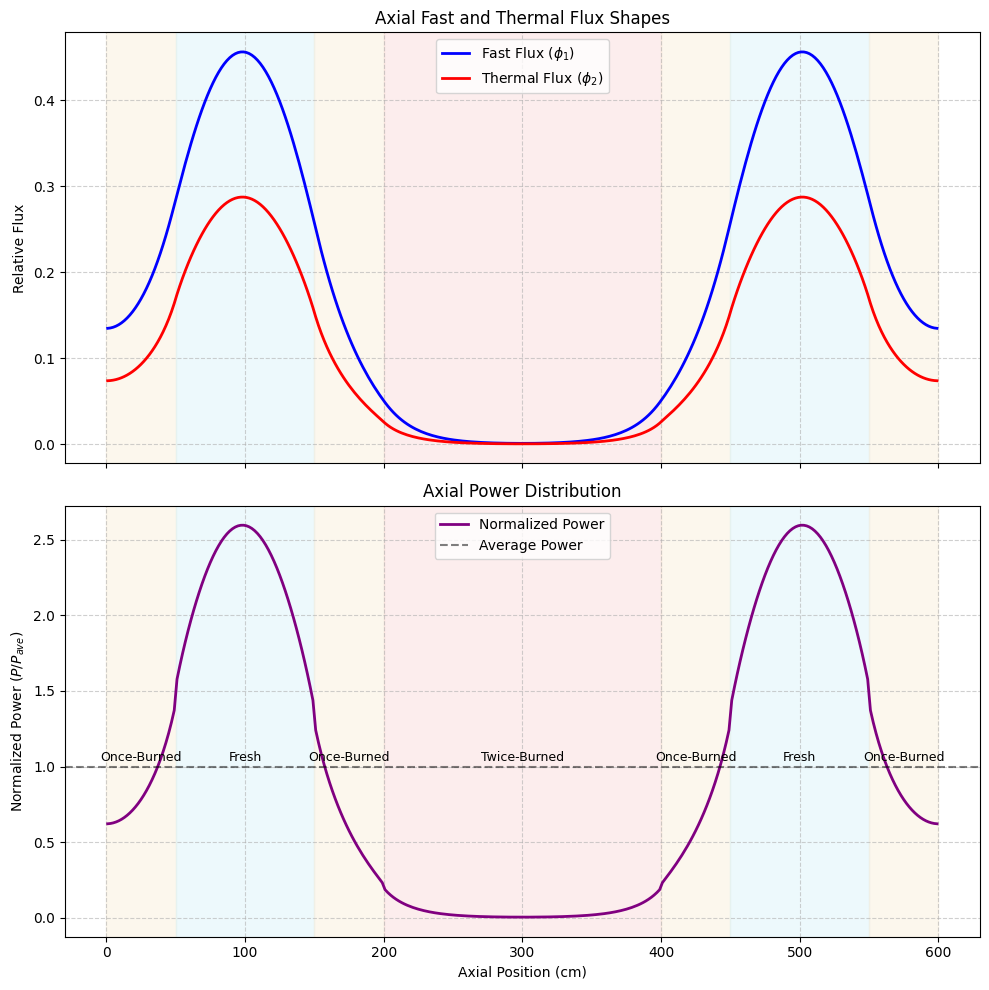

In [37]:
# Fuel properties given in Table 1
fresh = {"D1": 1.55, "D2": 0.82, "Sa1": 0.0012, "Sa2": 0.0105, "Ss12": 0.0068, "nSf1": 0.00035, "nSf2": 0.0145}
once  = {"D1": 1.50, "D2": 0.80, "Sa1": 0.0016, "Sa2": 0.0125, "Ss12": 0.0065, "nSf1": 0.00045, "nSf2": 0.0132}
twice = {"D1": 1.45, "D2": 0.78, "Sa1": 0.0021, "Sa2": 0.0155, "Ss12": 0.0062, "nSf1": 0.00055, "nSf2": 0.0115}

# Chosen core layout based on testing
core_layout_1 = [

    make_region(once,  50, 25, "Once-Burned"),

    make_region(fresh,  100, 50, "Fresh"),

    make_region(once,  50, 25, "Once-Burned"),

    make_region(twice,  200, 100, "Twice-Burned"),

    make_region(once,  50, 25, "Once-Burned"),

    make_region(fresh,  100, 50, "Fresh"),
    
    make_region(once,  50, 25, "Once-Burned"),
]

x, phi1, phi2, k, nSf1, nSf2 = solve_two_group_k_eigenvalue(core_layout_1, bc_type="reflecting")
output_results(x, phi1, phi2, k, nSf1, nSf2, core_layout_1)


**Hand Calculation Verification**

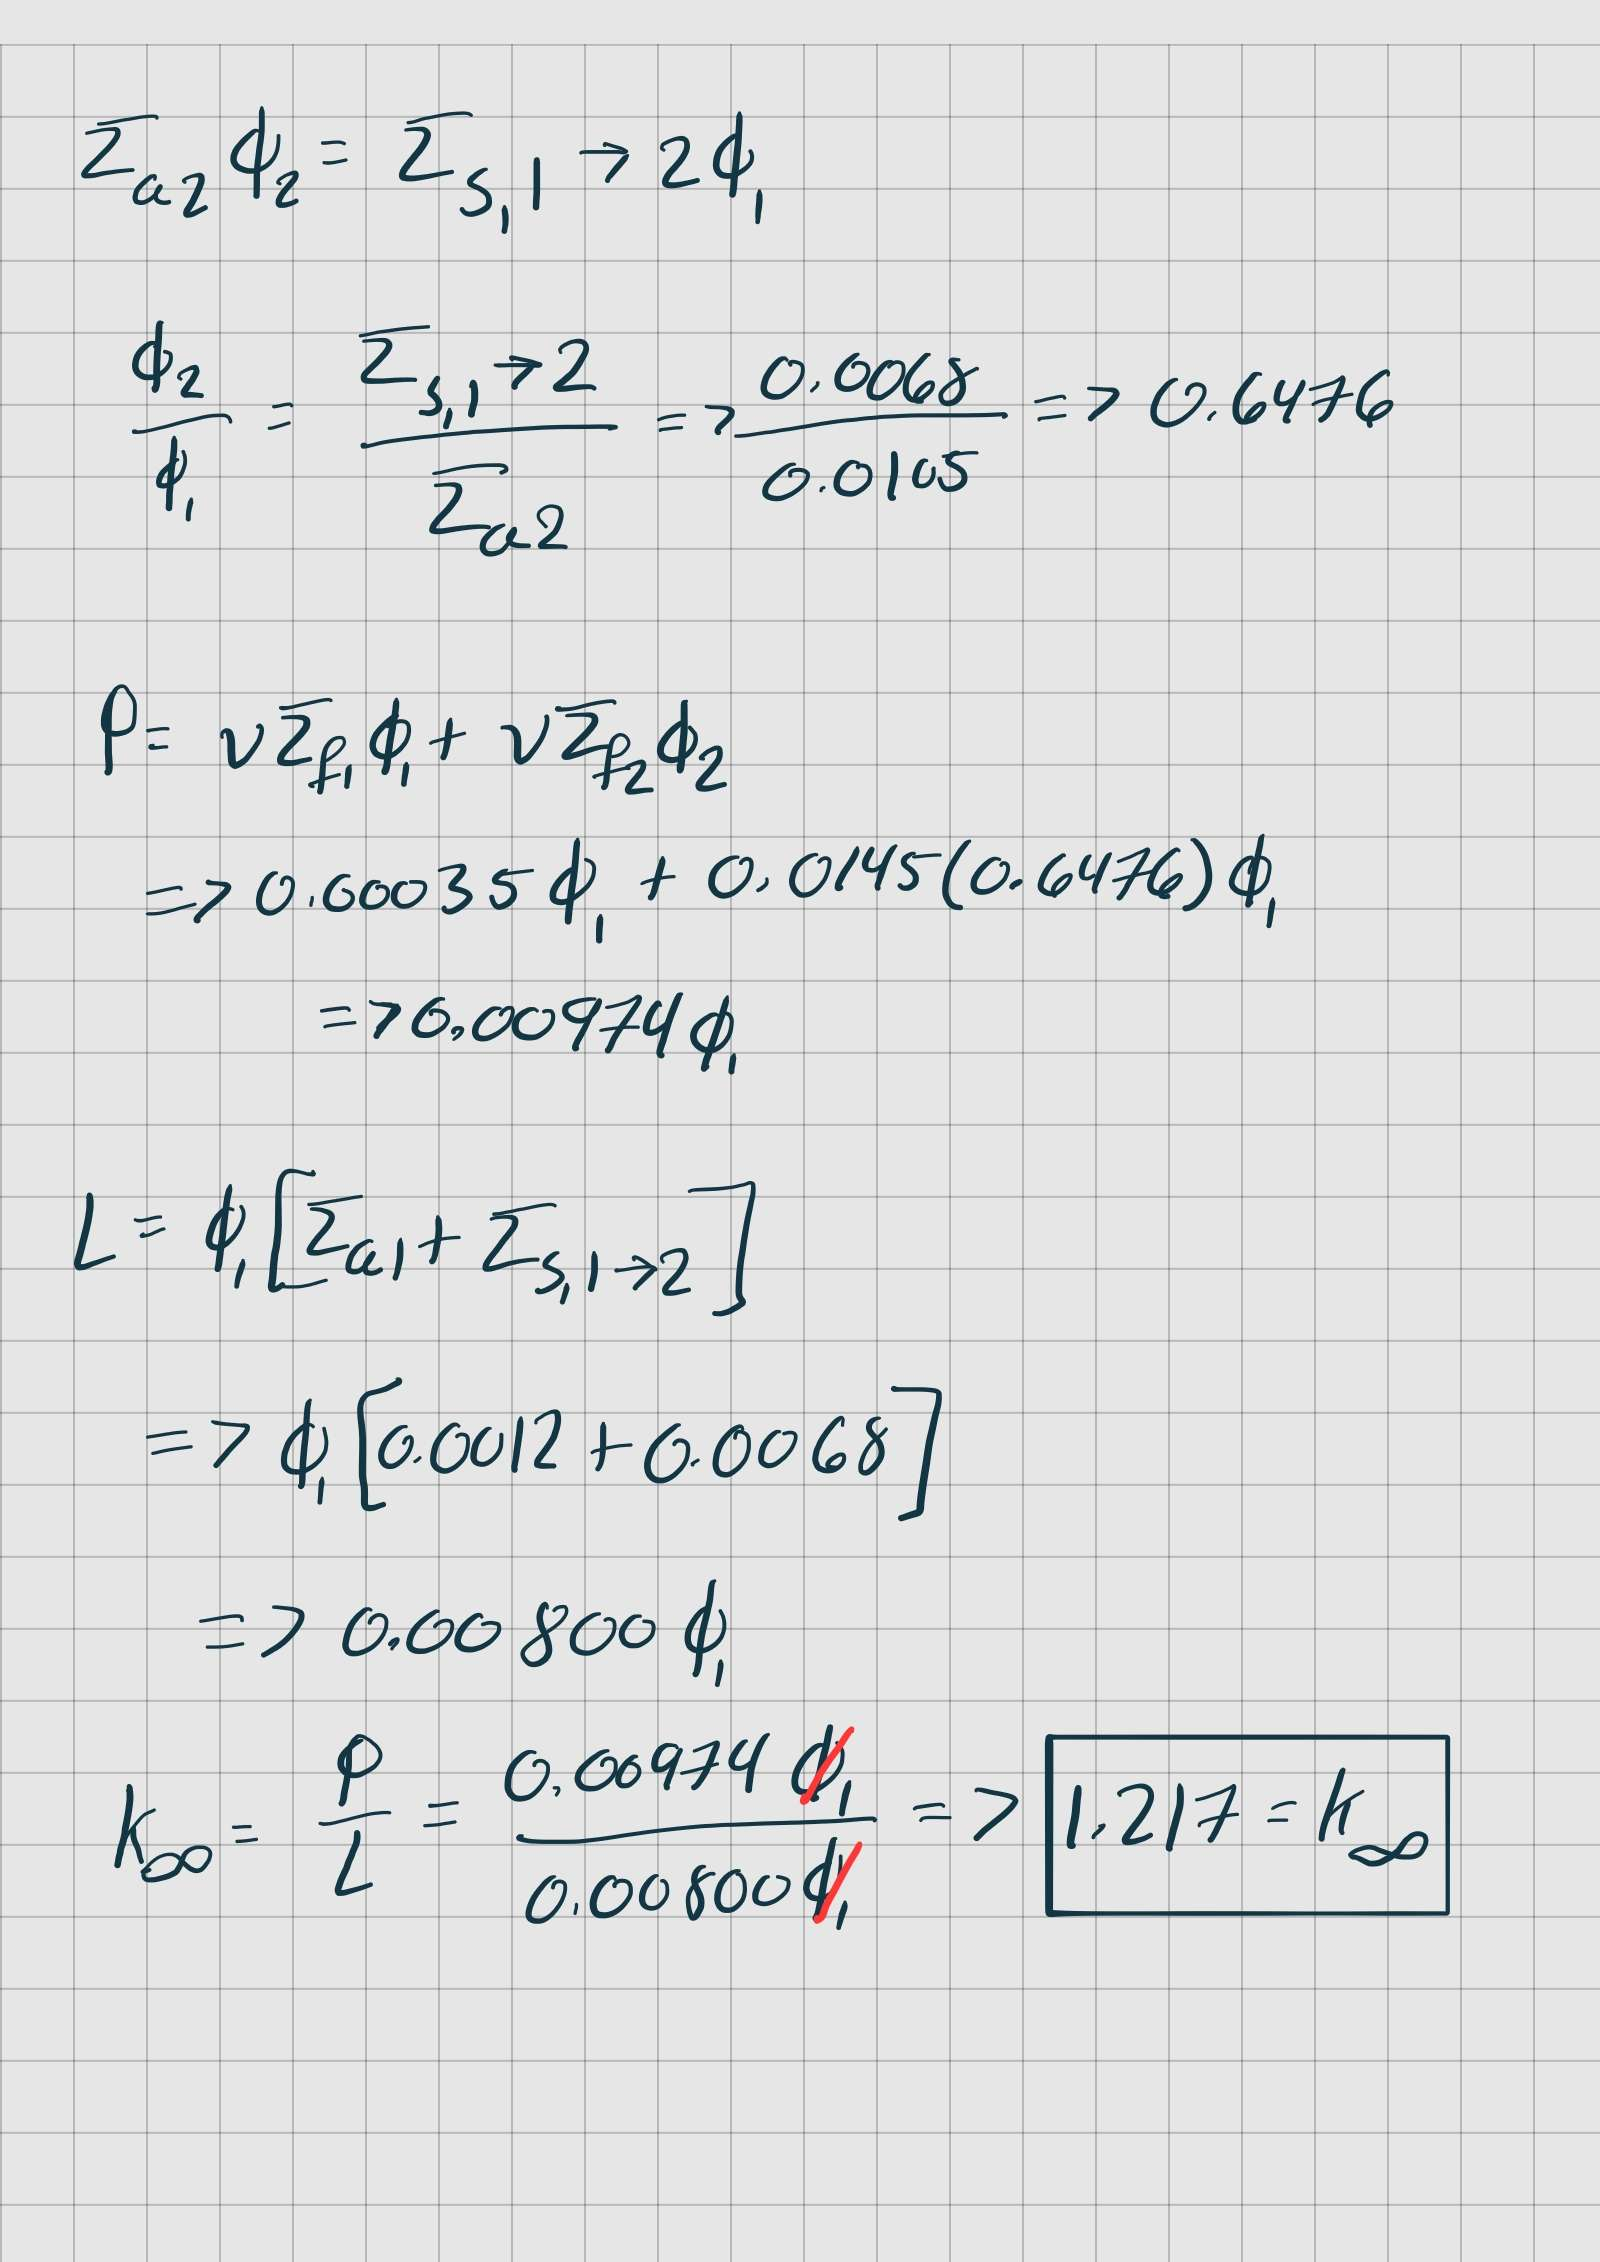

In [38]:
verification_core = [
    make_region(fresh, 600, 300, "Fresh")
]

x, phi1, phi2, k, nSf1, nSf2 = solve_two_group_k_eigenvalue(
    verification_core,
    bc_type="reflecting"
)

print(f"Numerical k = {k:.5f}")

Numerical k = 1.21756


# **Part 2: Extensions of the core design**

Modifying the 1D axial code to model a 2D cylindrical core, with the assumption that the core is radially homogenous in each axial region. So, the two-group fluxes obey the following equations in each axial region:
<br><br>

\begin{align}
&-\frac{D_1(z)}{r} \frac{\partial}{\partial r} \left( r \frac{\partial \phi_1(r, z)}{\partial r} \right) - \frac{\partial}{\partial z} \left( D_1(z) \frac{\partial \phi_1(r, z)}{\partial z} \right) \nonumber \\
&+\Sigma_{r,1}(z)\phi_1(r, z) = \frac{1}{k} \left( \nu\Sigma_{f,1}(z)\phi_1(r, z) + \nu\Sigma_{f,2}(z)\phi_2(r, z) \right) \tag{3} \\[10pt]
&-\frac{D_2(z)}{r} \frac{\partial}{\partial r} \left( r \frac{\partial \phi_2(r, z)}{\partial r} \right) - \frac{\partial}{\partial z} \left( D_2(z) \frac{\partial \phi_2(r, z)}{\partial z} \right) \nonumber \\
&+\Sigma_{a,2}(z)\phi_2(r, z) = \Sigma_{s,1\to2}(z)\phi_1(r, z) \tag{4}
\end{align}

<br><br>
To simplify this, we assume that the flux $\phi(r,z)$ is a separable function of $r$ and $z$: $\phi(r,z)=\Psi(r)\Phi(z)$, and substitute this in to the 2D diffusion equations
<br><br><br>
This is rearranged to obtain the form of $F(r) = G(z)$, and the only way this equation is true for all $r$ and $z$ is if $F(r) = G(z) =$ constant.
<br><br><br>



### **Separating and rearranging equations:**

Plugging in our substitution, we get:

$$- \frac{D_1(z)}{r} \frac{\partial}{\partial r} \left( r \frac{\partial [\Psi(r)\Phi_1(z)]}{\partial r} \right) - \frac{\partial}{\partial z} \left( D_1(z) \frac{\partial [\Psi(r)\Phi_1(z)]}{\partial z} \right) + \Sigma_{r,1}(z)[\Psi(r)\Phi_1(z)] = \frac{1}{k} \left( \nu\Sigma_{f,1}(z)[\Psi(r)\Phi_1(z)] + \nu\Sigma_{f,2}(z)[\Psi(r)\Phi_2(z)] \right)$$

Partial derivateves with respect to $r$ will treat $z$-dependent terms as constants and vice versa, so we can pull out terms:

$$- D_1(z) \Phi_1(z) \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] - \Psi(r) \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] + \Sigma_{r,1}(z)\Psi(r)\Phi_1(z) = \frac{\Psi(r)}{k} \left( \nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z) \right)$$

Now, we can divide both sides by $\phi(r,z)=\Psi(r)\Phi(z)$ to get:

$$- \frac{D_1(z)}{\Psi(r)} \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] - \frac{1}{\Phi_1(z)} \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] + \Sigma_{r,1}(z) = \frac{1}{k} \left( \frac{\nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z)}{\Phi_1(z)} \right)$$

Then, we move all other terms than the $r$ dependent piece to the right of the equals sign, and divide by $D_1(z)$ to get an equation where the left side is a function of $r$, and the right as a function of $z$:

$$-\frac{1}{\Psi(r)} \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] = \frac{1}{D_1(z)} \left( \frac{1}{\Phi_1(z)} \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] - \Sigma_{r,1}(z) + \frac{1}{k} \left[ \frac{\nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z)}{\Phi_1(z)} \right] \right)$$

Like said before, since each side is independent, we could hold $z$ the same while changing $r$, and the equation would have to stay equal, so both sides must be equal to a constant. To focus on the $r$ side, with our constant being the radial geometric buckling $B_r^2$:

$$-\frac{1}{\Psi(r)} \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] = B_r^2$$

Rearranging this, we can get the equation into this format:

$$\frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) + B_r^2 \Psi(r) = 0$$

Now, focusing on the $z$ side of the equation, setting it equal to $B_r^2$:
$$\frac{1}{D_1(z)} \left( \frac{1}{\Phi_1(z)} \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] - \Sigma_{r,1}(z) + \frac{1}{k} \left[ \frac{\nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z)}{\Phi_1(z)} \right] \right) = B_r^2$$

Multiplying both sides by $D_1(z)\Psi_1(z)$ to clear the fractions and rearranging:
$$-\frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) + \left[ \Sigma_{r,1}(z) + D_1(z)B_r^2 \right] \Phi_1(z) = \frac{1}{k}\left( \nu\Sigma_{f,1}(z)\phi_1(r, z) + \nu\Sigma_{f,2}(z)\phi_2(r, z) \right)$$

$\nu\Sigma_{f,1}(z)\phi_1(r, z) + \nu\Sigma_{f,2}(z)\phi_2(r, z)$ is simply written as $S_f(z)$ like in our 1D equations from part 1: 

$$-\frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) + \left[ \Sigma_{r,1}(z) + D_1(z)B_r^2 \right] \Phi_1(z) = \frac{1}{k} S_f(z)$$

This form is identical to our fast group equation from the 1D equations, except the physical removal cross section has another term to it: 

$$-\frac{\partial}{\partial z}\left(D_1(z) \frac{\partial \phi_1}{\partial z}\right) + \Sigma_{r,1}(z)\phi_1 = \frac{1}{k} S_f(z)$$

So from this, our new leakage cross section is now:

$$\Sigma_{r,1, \text{new}}(z) = \Sigma_{r,1}(z) + D_1(z) B_r^2$$

Which accounts for the fact that neutrons are now escaping horizontally out of the cylinder's radial boundaries



### **Summary and recap:**
- we plug $\phi(r,z)=\Psi(r)\Phi(z)$ into the 2D equations and rearranging into a format fitting $F(r) = G(z) = B_r^2$

- Isolating and rearranging both sides further, we get the two following equations:
$$\frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) + B_r^2 \Psi(r) = 0$$
$$\Sigma_{r,1, \text{new}}(z) = \Sigma_{r,1}(z) + D_1(z) B_r^2$$

### **Zero-order Bessel differential equation:**

The first equation we got is a zero-order Bessel differential equation. It is a second-order differential equation, so its general solution muust contain two independent functions and two constants of integration:

$$\Psi(r)=AJ_0(B_rr)+CY_0(B_rr)$$

$J_0$ here is the Bessel function of the first kind of order zero. $Y_0$ is the Bessel function of the second kind of order zero.

At $r=0$ in the core of the reactor, $J_0()=1$, which is a perfectly fine and finite answer, but as $r$ approaches 0, $Y_0(B_rr)=-\infty$, which is not physically possible. This means $C$ must be equal to 0 for the equation to remain finite, so our equation simplifies further to:

$$\Psi(r)=AJ_0(B_rr)$$

Applying the other boundary contition at the outer edge, if we assume it will be a vacuum the neutron flux will drop to zero.

$$J_0(B_rR)=0$$

Thsi means $J_0$ is zero with this value. Looking at the Bessel function roots, the first is at $J_0(2.4048)=0$, and the reactor's flux cannot be negative so this is the only root we care about. This means that $B_rR=2.4048$. We know that the radius of our reactor is 4m or 400cm. Thus, we can find the radial buckling:

$$B_r^2=\left(\frac{2.40483}{400 \text{ cm}}\right) = 0.000036145 \text{ cm}^{-2}$$


### **Part 2.1 Code**:

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0, j1
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

### **solve_2d_cylindrical_eigenvalue:**

Modified 2D two-group core solver

In [40]:
def solve_2d_cylindrical_eigenvalue(
    regions,
    Br2,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500,
    bc_type="reflecting"
):
    x, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx = expand_regions(regions)
    N = len(x)

    # Removal cross sections, modified to include new radial leakage term (D * Br^2)
    Sr1 = Sa1 + Ss12 + (D1 * Br2)   # Fast removal: Absorption + Scattering + Radial Leakage
    Sr2 = Sa2 + (D2 * Br2)          # Thermal removal: Absorption + Radial Leakage

    # Building the loss matrices for both groups using the specified BC
    A1 = build_loss_matrix(D1, Sr1, dx, bc_type=bc_type)
    A2 = build_loss_matrix(D2, Sr2, dx, bc_type=bc_type)

    k = 1.0
    phi1 = np.ones(N)
    phi2 = np.ones(N)

    # Initial fission source
    fission_source = (nSf1 * phi1 + nSf2 * phi2) * dx
    fission_source /= np.sum(fission_source)


    for it in range(1, max_iters + 1):
        # Step 1: Solving fast group
        rhs1 = fission_source / k
        phi1_new = spsolve(A1, rhs1)

        # Step 2: Solving thermal group (source is from scattering from fast group)
        rhs2 = Ss12 * phi1_new * dx
        phi2_new = spsolve(A2, rhs2)

        # Step 3: Calculating new fission source
        fission_source_raw = (nSf1 * phi1_new + nSf2 * phi2_new) * dx
        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        # Step 4: Normalizing fluxes
        normalization_factor = np.sum(fission_source_raw)
        phi1_new /= normalization_factor
        phi2_new /= normalization_factor
        fission_source_new = fission_source_raw / normalization_factor

        # Step 5: Checking for convergence
        k_error = abs(k_new - k) / abs(k)
        source_error = np.linalg.norm(fission_source_new - fission_source, ord=np.inf) / np.linalg.norm(fission_source, ord=np.inf)


        if k_error < k_tol and source_error < source_tol:
            return x, phi1_new, phi2_new, k_new, nSf1, nSf2
        
        k = k_new
        phi1 = phi1_new
        phi2 = phi2_new
        fission_source = fission_source_new
    
    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi1_new, phi2_new, k_new, nSf1, nSf2

### **Execution of code for part 2.1 of project**

Radial Buckling (Br^2): 3.614505e-05 cm^-2
--- 2D Cylindrical Reactor Results ---
2D k-effective: 1.09853
2D Power Peaking Factor: 6.01852


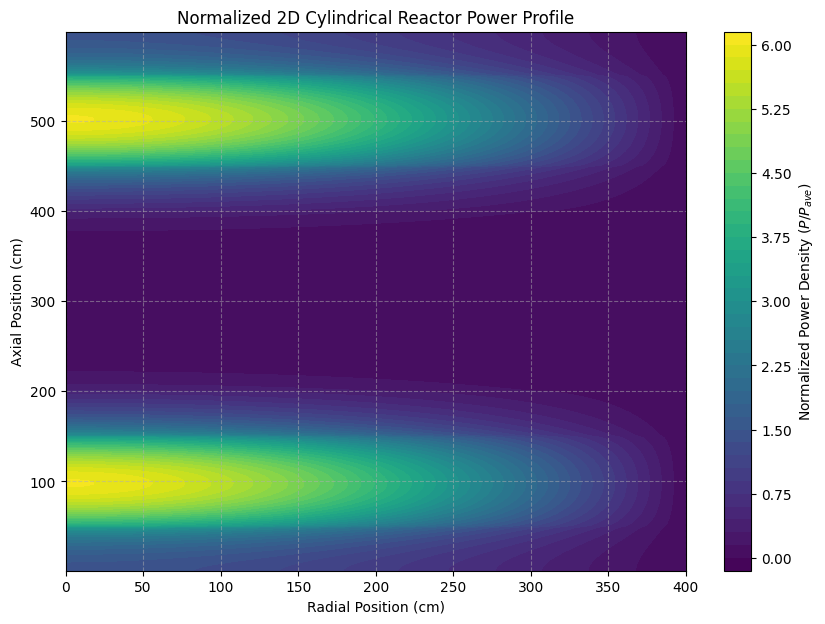

In [41]:
# Core dimensions:

R_core = 400.0 #cm, or 4 meters tall
H_core = 600.0 #cm, or 6 meters tall

# Calculate constant radial buckling:
bessel_zero = 2.40483
Br = bessel_zero / R_core
Br2 = Br**2

print(f"Radial Buckling (Br^2): {Br2:.6e} cm^-2")

# Define radial grid for plotting and analysis
num_r_points = 50
r_grid = np.linspace(0, R_core, num_r_points)

# Analytical radial flux shape normalized to an average value of 1.0
# The average of J0(Br*r) over the cross-section is (2 * J1(Br*R)) / (Br*R)
radial_avg_j0 = (2.0 * j1(bessel_zero)) / bessel_zero
radial_power_shape = j0(Br * r_grid) / radial_avg_j0

# Executing code using fuel layout from Section 1
x_centers, phi1_2d, phi2_2d, k_2d, nSf1_arr, nSf2_arr = solve_2d_cylindrical_eigenvalue(core_layout_1, Br2, bc_type="reflecting")

# Calculate normalized axial power distribution
axial_power = nSf1_arr * phi1_2d + nSf2_arr * phi2_2d
axial_power_norm = axial_power / np.mean(axial_power)

# Use Meshgrid to superimpose profiles across 2D space
R_mesh, Z_mesh = np.meshgrid(r_grid, x_centers)
P_mesh = np.zeros_like(R_mesh)

for i in range(len(x_centers)):
    P_mesh[i, :] = axial_power_norm[i] * radial_power_shape

# Calculate final power peaking factor for the assembly
ppf_2d = np.max(P_mesh) / 1.0  # Normalized average is 1.0
print(f"--- 2D Cylindrical Reactor Results ---")
print(f"2D k-effective: {k_2d:.5f}")
print(f"2D Power Peaking Factor: {ppf_2d:.5f}")

# Render the Plot
plt.figure(figsize=(10, 7))
contour = plt.contourf(R_mesh, Z_mesh, P_mesh, 50, cmap='viridis')
plt.colorbar(contour, label=r"Normalized Power Density ($P / P_{ave}$)")
plt.title("Normalized 2D Cylindrical Reactor Power Profile")
plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Part 2.2: Pebble temperature distributions**:

Core volume = 301.593 m^3
Average power density = 6.631e+05 W/m^3

Maximum centerline temperature = 936.96 K
Minimum centerline temperature = 900.00 K

Hottest location:
r = 0.00 cm
z = 99.00 cm


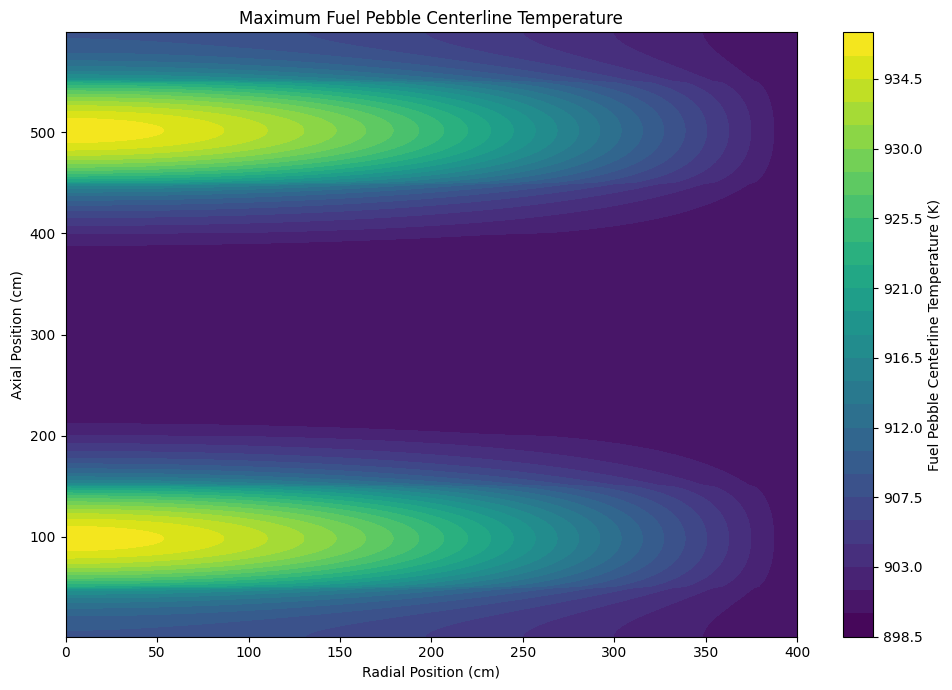

In [42]:
import numpy as np
import matplotlib.pyplot as plt


# Thermal parameters from Table 2
T_cool = 900.0      # K
rf = 0.025          # m
tc = 0.005          # m
ro = rf + tc        # m
kf = 20.0           # W/m-K
kc = 30.0           # W/m-K
h = 2000.0          # W/m^2-K

# Core geometry
R_core = 4.0        # m
H_core = 6.0        # m
P_core = 200e6      # W

# Average volumetric power density
V_core = np.pi * R_core**2 * H_core
q_avg = P_core / V_core

print(f"Core volume = {V_core:.3f} m^3")
print(f"Average power density = {q_avg:.3e} W/m^3")

# Local power density
q_local = q_avg * P_mesh

# Temperature rise components
Q_pebble = q_local * (4/3) * np.pi * rf**3 # heat leaving one pebble
A_pebble = 4 * np.pi * ro**2               # pebble surface area
dT_conv = Q_pebble / (h * A_pebble)        # convection rise

dT_coating = (                             # graphite coating rise
    q_local * rf**3 / (3 * kc)
    * (1/rf - 1/ro))
dT_fuel = q_local * rf**2 / (6 * kf)       # fuel-center rise

T_center = (                               # total centerline temperature
    T_cool
    + dT_conv
    + dT_coating
    + dT_fuel)

# Results
print(f"\nMaximum centerline temperature = {np.max(T_center):.2f} K")
print(f"Minimum centerline temperature = {np.min(T_center):.2f} K")

imax = np.unravel_index(np.argmax(T_center), T_center.shape) # location of hottest pebble

print("\nHottest location:")
print(f"r = {R_mesh[imax]:.2f} cm")
print(f"z = {Z_mesh[imax]:.2f} cm")

# Plotting
plt.figure(figsize=(10,7))

cont = plt.contourf(
    R_mesh,
    Z_mesh,
    T_center,
    levels=30)

plt.colorbar(cont,
             label="Fuel Pebble Centerline Temperature (K)")

plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.title("Maximum Fuel Pebble Centerline Temperature")

plt.tight_layout()
plt.show()

# **Part 3 Extra Credit: Albedo Boundary Condition**

In the two-dimensional cylindrical reactor model, the radial component of the neutron flux satisfies the diffusion equation

$$ \frac{1}{r}\frac{d}{dr}\left(r\frac{dR}{dr}\right)+B_r^2R=0 $$

where $B_r$ is the radial buckling. The finite solution at the centerline of the reactor is

$$ R(r)=AJ_0(B_r r) $$

where $J_0$ is the zeroth-order Bessel function of the first kind.

The neutron current is given by Fick's Law,

$$ J(r)=-D\frac{dR}{dr}. $$

Using the identity

$$ \frac{dJ_0(x)}{dx}=-J_1(x), $$

the radial current becomes

$$ J(r)=DAB_rJ_1(B_r r). $$

At the reactor boundary $r=R$, the flux and current are

$$ \phi(R)=AJ_0(B_rR) $$


and

$$ J(R)=DAB_rJ_1(B_rR). $$

Using the diffusion-theory definitions of outgoing and incoming partial currents,

$$ J^{+}=\frac{\phi}{4}+\frac{J}{2} $$

and

$$ J^{-}=\frac{\phi}{4}-\frac{J}{2}, $$

the albedo boundary condition is

$$ J^{-}(R)=\alpha J^{+}(R), $$

where $\alpha$ is the neutron albedo.

Substituting the expressions for the flux and current gives

$$ \frac14 J_0(B_rR)-\frac12 DB_rJ_1(B_rR) = \alpha\left(\frac14 J_0(B_rR)+\frac12 DB_rJ_1(B_rR)\right). $$

Rearranging,

$$ (1-\alpha)J_0(B_rR) = 2(1+\alpha)DB_rJ_1(B_rR). $$

Therefore, the radial buckling is determined by the transcendental equation

$$ (1-\alpha)J_0(B_rR) - 2(1+\alpha)DB_rJ_1(B_rR) = 0. $$

This expression reduces to the expected limiting cases.

**Vacuum Boundary ($\alpha = 0$)**

$$ J_0(B_rR)-2DB_rJ_1(B_rR)=0, $$

which is the standard Marshak vacuum boundary condition.

**Reflecting Boundary ($\alpha = 1$)**

$$ J_1(B_rR)=0. $$

The fundamental solution is $B_r=0$, implying no radial leakage and recovering the axial-only model.

Once $B_r$ is determined, the radial diffusion term can be replaced by an equivalent leakage cross section. The resulting one-dimensional axial diffusion equations become

$$ -\frac{d}{dz}\left(D_1\frac{d\phi_1}{dz}\right) + \left(\Sigma_{r,1}+D_1B_r^2\right)\phi_1 = \frac{1}{k}\left(\nu\Sigma_{f,1}\phi_1 + \nu\Sigma_{f,2}\phi_2\right) $$

and

$$ -\frac{d}{dz}\left(D_2\frac{d\phi_2}{dz}\right) + \left(\Sigma_{a,2}+D_2B_r^2\right)\phi_2 = \Sigma_{s,1\rightarrow2}\phi_1. $$

Thus, the effect of the albedo boundary condition is incorporated through the modified radial buckling $B_r$, which changes the radial leakage term

$$ \Sigma_{\text{leak},g}=D_gB_r^2. $$

As the albedo increases from 0 to 1, radial leakage decreases, causing the multiplication factor to increase and approach the axial-only solution in the limit of a perfectly reflecting boundary.

alpha = 0.25
Br = 5.937403e-03 cm^-1
Br² = 3.525275e-05 cm^-2

--- 2D Cylindrical Reactor Results ---
2D k-effective = 1.09878
2D Power Peaking Factor = 5.87247


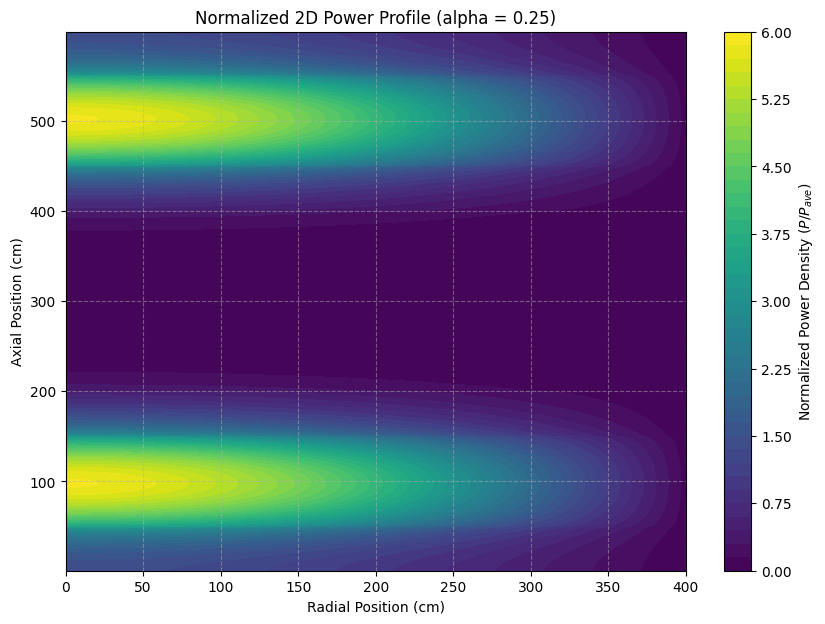

ALBEDO PARAMETRIC STUDY
alpha = 0.00 | Br² = 3.560684e-05 | k = 1.09868
alpha = 0.25 | Br² = 3.525275e-05 | k = 1.09878
alpha = 0.50 | Br² = 3.455591e-05 | k = 1.09898
alpha = 0.75 | Br² = 3.255880e-05 | k = 1.09954
alpha = 1.00 | Br² = 0.000000e+00 | k = 1.10878


In [67]:
from scipy.optimize import brentq
from scipy.special import j0, j1
import numpy as np
import matplotlib.pyplot as plt

R_core = 400.0   # cm
H_core = 600.0   # cm

# User-specified albedo
alpha = 0.25      # 0 = vacuum, 1 = reflecting


# Solve for buckling from:
#
# (1-alpha)J0(BR)
# - 2(1+alpha)DBJ1(BR) = 0

def albedo_buckling(alpha, R_core, D_eff):
    if np.isclose(alpha, 1.0):
        return 0.0, 0.0
    def f(B):
        return (
            (1.0 - alpha) * j0(B * R_core)
            - 2.0 * (1.0 + alpha)
            * D_eff
            * B
            * j1(B * R_core))
    B_vac = 2.40483 / R_core
    left = 0.2 * B_vac
    right = 2.0 * B_vac

    while f(left) * f(right) > 0:
        left *= 0.5
        right *= 1.5
        if right > 0.1:
            raise RuntimeError("Could not bracket albedo buckling root.")

    Br = brentq(f, left, right)

    return Br, Br**2

# Effective diffusion coefficient

D_eff = np.mean([1.55, 1.50, 1.45])

Br, Br2 = albedo_buckling(
    alpha,
    R_core,
    D_eff
)

print(f"alpha = {alpha:.2f}")
print(f"Br = {Br:.6e} cm^-1")
print(f"Br² = {Br2:.6e} cm^-2")

# Radial grid
num_r_points = 50
r_grid = np.linspace(
    0,
    R_core,
    num_r_points)

# Radial power shape
if Br > 0:
    x_boundary = Br * R_core
    radial_avg_j0 = (
        2.0 * j1(x_boundary)
        / x_boundary)
    radial_power_shape = (
        j0(Br * r_grid)
        / radial_avg_j0)
else:
    radial_power_shape = np.ones_like(r_grid)


# Solve 2D reactor
(
    x_centers,
    phi1_2d,
    phi2_2d,
    k_2d,
    nSf1_arr,
    nSf2_arr) = solve_2d_cylindrical_eigenvalue(
    core_layout_1,
    Br2,
    bc_type="reflecting")

# Axial power
axial_power = (
    nSf1_arr * phi1_2d
    + nSf2_arr * phi2_2d)

axial_power_norm = (
    axial_power
    / np.mean(axial_power))

# Build 2D power distribution
R_mesh, Z_mesh = np.meshgrid(
    r_grid,
    x_centers)

P_mesh = np.zeros_like(R_mesh)

for i in range(len(x_centers)):
    P_mesh[i, :] = (
        axial_power_norm[i]
        * radial_power_shape)

# Results
ppf_2d = np.max(P_mesh)

print("\n--- 2D Cylindrical Reactor Results ---")
print(f"2D k-effective = {k_2d:.5f}")
print(f"2D Power Peaking Factor = {ppf_2d:.5f}")


# Plot power profile

plt.figure(figsize=(10,7))

contour = plt.contourf(
    R_mesh,
    Z_mesh,
    P_mesh,
    50,
    cmap="viridis")

plt.colorbar(
    contour,
    label=r"Normalized Power Density ($P/P_{ave}$)")

plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.title(
    f"Normalized 2D Power Profile (alpha = {alpha:.2f})")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# Verify alpha -> 0 and alpha -> 1 limits
print("======================================")
print("ALBEDO PARAMETRIC STUDY")
print("======================================")

alphas = [0.0, 0.25, 0.50, 0.75, 1.00]

for alpha_test in alphas:

    D_eff = np.mean([1.55, 1.50, 1.45])

    Br_test, Br2_test = albedo_buckling(
        alpha_test,
        R_core,
        D_eff)

    (
        _,
        _,
        _,
        k_test,
        _,
        _ 
    ) = solve_2d_cylindrical_eigenvalue(
        core_layout_1,
        Br2_test,
        bc_type="reflecting")

    print(
        f"alpha = {alpha_test:.2f} | "
        f"Br² = {Br2_test:.6e} | "
        f"k = {k_test:.5f}")